# 10 — Robustness appendix: the seed

`discrete` mode draws a lognormal size and a uniform coin per candle per
direction, so **the whole matrix is one realisation of a random process**. Every
number reported from it comes from seed 0.

Under `share` the question did not arise — that mode is deterministic. The
randomness was introduced deliberately, to get the one-sided order flow that
makes the arbitrageur's presence meaningful, and this appendix is its price.

**The verdict rule was fixed before this ran** (see
`2026-08-10-r-correction-preregistration.md`): a policy whose median keeps its
sign across all five seeds may be reported as beating — or losing to — the
baseline. One whose sign flips on any seed may be reported **per seed only**. The
spread across seeds travels with the verdict either way, because a unanimous sign
with a wide spread is still weak evidence.

**Needs:** `results/sensitivity/seeds.csv` from

```bash
uv run python -m experiments.seed_robustness      # 960 cells, ~15 min
```

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.seed_robustness import SEEDS, analyse, paths_for, stability

FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)

# Same switch as notebooks 07 and 08. The appendix is required at BOTH operating
# points on the same terms, and the two must not overwrite each other's figure.
CONFIGS = {
    "headline": {"turnover": 1.0, "prefix": "", "label": "κ = 1.0 (calibrated)"},
    "informed": {"turnover": 0.1, "prefix": "t01_", "label": "κ = 0.1"},
}
CONFIG = os.environ.get("UU_CONFIG", "headline")
assert CONFIG in CONFIGS, f"UU_CONFIG must be one of {sorted(CONFIGS)}"
TURNOVER = CONFIGS[CONFIG]["turnover"]
PREFIX = CONFIGS[CONFIG]["prefix"]
LABEL = CONFIGS[CONFIG]["label"]

RESULTS, STEM = paths_for(TURNOVER)
frame = pd.read_csv(RESULTS / f"{STEM}.csv")
ok = frame[frame["error"].isna()]
worst = ok[["conservation_error_token0", "conservation_error_token1"]].abs().max().max()
print(f"operating point: {CONFIG} — {LABEL}, from {RESULTS.relative_to(ROOT)}/")
print(
    f"{len(frame)} cells over seeds {list(SEEDS)}, "
    f"{int(frame['error'].notna().sum())} errors"
)
print(f"worst conservation error: {worst:.2e}")
assert frame["error"].notna().sum() == 0 and worst < 1e-6

# The axis this operating point is selected on, measured rather than assumed.
arb = ok["arb_volume"].sum()
print(f"arbitrage share of volume: {arb / (arb + ok['uu_volume'].sum()):.3f}")

operating point: headline — κ = 1.0 (calibrated), from results/sensitivity/
960 cells over seeds [0, 1, 2, 3, 4], 0 errors
worst conservation error: 5.47e-16
arbitrage share of volume: 0.117


## Every seed, side by side

The baseline is re-paired **within** each seed: pairing across seeds would
compare two different realisations of the draw, which is not a comparison of
policies at all.

In [2]:
tests = analyse(frame, write=False, turnover=TURNOVER)
end = tests[tests["valuation"] == "net_result"]
end.pivot_table(index=["pair", "policy"], columns="seed", values="median").round(1)

seed                 0      1      2      3      4
pair     policy                                   
ETH/SHIB ABHook -222.1 -264.8 -327.5 -268.7 -247.2
         BAHook   22.3  174.4   53.3  696.5  651.2
         DAHook  283.8  247.2   93.9  554.7  738.1
ETH/USDC ABHook -366.1 -339.8 -334.8 -167.9 -285.6
         BAHook  156.7   25.9  280.8  284.9  442.2
         DAHook  602.0  387.0  358.3  232.2  880.6

## The verdict, and the spread beside it

In [3]:
table = stability(tests)
table.round(1)

,pair,policy,seeds,seeds_positive,unanimous,median_min,median_median,median_max,spread
0,ETH/SHIB,ABHook,5,0,True,-327.5,-264.8,-222.1,105.4
1,ETH/SHIB,BAHook,5,5,True,22.3,174.4,696.5,674.2
2,ETH/SHIB,DAHook,5,5,True,93.9,283.8,738.1,644.2
3,ETH/USDC,ABHook,5,0,True,-366.1,-334.8,-167.9,198.2
4,ETH/USDC,BAHook,5,5,True,25.9,280.8,442.2,416.3
5,ETH/USDC,DAHook,5,5,True,232.2,387.0,880.6,648.4


In [4]:
flipped = table[~table["unanimous"]]
if len(flipped):
    print("NOT unanimous — these may be reported per seed only:")
    display(flipped[["pair", "policy", "seeds_positive", "seeds"]])
else:
    print("Every policy keeps its sign across all seeds.")
    print("The sign of each advantage may be reported; the size may not.")

widest = table.loc[table["spread"].idxmax()]
print(
    f"\nwidest: {widest.policy} on {widest.pair} spans "
    f"{widest.median_min:+,.0f} to {widest.median_max:+,.0f} USDT "
    f"({widest.median_max / max(widest.median_min, 1):.0f}x) around a median of "
    f"{widest.median_median:+,.0f}"
)

Every policy keeps its sign across all seeds.
The sign of each advantage may be reported; the size may not.

widest: BAHook on ETH/SHIB spans +22 to +696 USDT (31x) around a median of +174


**The sign is robust; the magnitude is not.** That distinction is the whole
output of this appendix, and the paper carries both halves: the sign of each
policy's advantage over the baseline survives every realisation of the flow, and
no single number may be quoted for its size.

### The magnitudes here are NOT comparable to the matrix's

The appendix runs 8 windows per tercile and one gas scenario; the matrix runs 24
and three. **Its 24-window subset is not representative of the 72**, and not in a
consistent direction — on ETH/SHIB at 20 gwei, `DAHook`'s median difference is:

| | this subset | all 72 windows |
| --- | ---: | ---: |
| κ = 1.0 | +284 | **+484** |
| κ = 0.1 | +350 | **+196** |

So the subset understates the advantage at one operating point and nearly
doubles it at the other. Earlier prose here said "the medians sit below the
matrix's" — true at κ = 1.0 by accident, false at κ = 0.1. **Read this appendix
for sign and spread only.** For a magnitude, use the matrix.

What does transfer is the integrity check: seed 0 of this appendix reproduces the
matrix **bit for bit** on all 192 cells the two share, at both operating points.

> **What this does not establish.** The comparison here is against the
> pre-registered static 30 bps, so "survives every seed" is a statement about
> that comparison only. Against the *best* static fee in the box the picture
> differs by operating point — see the post-hoc table in `PROGRESS.md` — and this
> appendix does not test it.

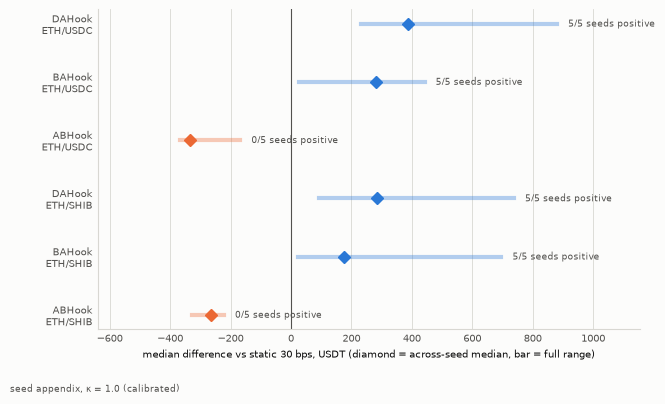

In [5]:
from IPython.display import Image, display

from experiments.figures import figure_note, seed_stability

with figure_note(f"seed appendix, {LABEL}"):
    for suffix in ("pdf", "png"):
        seed_stability(table, FIGURES / f"{PREFIX}seed_stability.{suffix}")
display(Image(filename=str(FIGURES / f"{PREFIX}seed_stability.png")))